# Sales Forecasting Project — MarketCorp
**Build an end-to-end sales forecasting pipeline.**

This notebook is a project workflow: we take MarketCorp’s historical sales data, clean and explore it, create clear business insights, and train a baseline model to **predict item outlet sales**.

Datasets used:
- `marketcorp_sales.csv` — historical training data
- `marketcorp_unseen_data.csv` — new/unseen data (optional) to practice making predictions

## Project roadmap

### M1: Setup & Quick Audit
1. Environment (Jupyter / VS Code) and imports
2. Load data + first quality checks
3. Quick NumPy → Pandas refresher

### M2: Cleaning & Feature Preparation
1. Handle missing values and inconsistent labels
2. Validate assumptions with simple checks
3. Prepare analysis-ready tables

### M3: Exploratory Analysis & Visualization
1. Target distribution and key drivers
2. Outlet and item performance summaries
3. Small “dashboard” plots for communication

### M4: Baseline Forecast Model (Optional)
1. Train/test split and preprocessing
2. Regression baseline and evaluation (MAE/RMSE)
3. Interpret results for decision-making

In [1]:
# M1 — Imports + notebook setup
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_DIR = Path(".")
SALES_PATH = DATA_DIR / "marketcorp_sales.csv"
UNSEEN_PATH = DATA_DIR / "marketcorp_unseen_data.csv"

In [ ]:
# M1 — NumPy: quick "table" 2D array demo
arr = np.array([
    [10,  2,  5],
    [12,  3,  6],
    [ 9,  4,  4],
])
print("Array shape:", arr.shape)
print("Column means:", arr.mean(axis=0))

# Converting to a DataFrame common workflow
arr_df = pd.DataFrame(arr, columns=["sales", "returns", "visits"])
display(arr_df)

Array shape: (3, 3)
Column means: [10.33333333  3.          5.        ]


,sales,returns,visits
0,10,2,5
1,12,3,6
2,9,4,4


In [ ]:
# M2 — Import data raw → DataFrame
df_raw = pd.read_csv(SALES_PATH)
display(df_raw.head())
print("Rows, columns:", df_raw.shape)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDG61,17.281082,reg,0.191732,Snack Foods,206.660678,OUT012,2004,Small,Tier 2,Supermarket Type1,2862.968738
1,FDO81,11.664071,Regular,0.000000,Household,77.860059,OUT036,1999,Small,Tier 2,Supermarket Type1,1631.656231
2,FDU92,18.154878,Low Fat,0.051269,Dairy,118.363505,OUT016,2004,Medium,Tier 2,Supermarket Type3,827.376492
3,FDW84,18.605568,Regular,0.063893,Meat,155.122827,OUT042,2004,Medium,Tier 2,Grocery Store,1009.552139
4,FDK97,8.391905,Low Fat,0.023267,Soft Drinks,170.986748,OUT018,1985,Small,Tier 3,Supermarket Type2,2169.485612


Rows, columns: (2000, 12)


In [ ]:
# M1 — Quick data audit types, missing values, basic stats
display(df_raw.dtypes)

missing = (df_raw.isna().sum().sort_values(ascending=False))
display(missing[missing > 0].to_frame("missing_count"))

# Compact overview
display(df_raw.describe(include="all").T.head(20))

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

,missing_count
Outlet_Size,509
Item_Weight,300


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,2000,1328,FDG61,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,1700.0,NaN,NaN,NaN,12.893839,4.626754,5.000186,8.868867,12.880836,16.872746,20.992923
Item_Fat_Content,2000,5,Low Fat,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,2000.0,NaN,NaN,NaN,0.085315,0.062582,0.0,0.039239,0.071906,0.1201,0.376628
Item_Type,2000,8,Household,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,2000.0,NaN,NaN,NaN,147.62143,66.397817,30.140676,90.909028,147.257228,204.616633,259.970431
Outlet_Identifier,2000,40,OUT046,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,2000.0,NaN,NaN,NaN,1998.7325,7.672769,1985.0,1997.0,1999.0,2004.0,2009.0
Outlet_Size,1491,3,Small,604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,2000,3,Tier 3,688,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# M1 — Missing values by segment example: Item_Type
missing_by_item_type = (
    df_raw.groupby("Item_Type", dropna=False)
    .apply(lambda g: g.isna().sum())
    .sort_index()
)
display(missing_by_item_type)

## M2  Cleaning raw to analysis ready

Goal: fix common data quality issues with **simple, explainable rules**.

In [ ]:
# M2 — Cleaning rules beginner friendly
df = df_raw.copy()

# 1) Some files store missing Outlet_Size as the *text* 'nan'
df["Outlet_Size"] = df["Outlet_Size"].replace("nan", np.nan)

# 2) Item_Weight: fill missing with the global mean
weight_mean = df["Item_Weight"].mean()
df["Item_Weight"] = df["Item_Weight"].fillna(weight_mean)

# 3) Outlet_Size: fill missing with a label
df["Outlet_Size"] = df["Outlet_Size"].fillna("Unknown")

# 4) Item_Visibility: 0.0 is likely invalid → replace 0 with median of non-zero values
median_visibility = df.loc[df["Item_Visibility"] > 0, "Item_Visibility"].median()
df.loc[df["Item_Visibility"] == 0, "Item_Visibility"] = median_visibility

# 5) Standardize fat content labels
fat_fix = {"low fat": "Low Fat", "LF": "Low Fat", "reg": "Regular"}
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace(fat_fix)

print("Any missing left?", df.isna().any().any())
display(df.isna().sum().sort_values(ascending=False).head(10))
display(df[["Item_Weight", "Item_Visibility", "Outlet_Size", "Item_Fat_Content"]].head())

Any missing left? False


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
dtype: int64

,Item_Weight,Item_Visibility,Outlet_Size,Item_Fat_Content
0,17.281082,0.191732,Small,Regular
1,11.664071,0.076299,Small,Regular
2,18.154878,0.051269,Medium,Low Fat
3,18.605568,0.063893,Medium,Regular
4,8.391905,0.023267,Small,Low Fat


## M2  Manipulation with Pandas selection, filtering, groupby

We’ll answer practical questions like:
1. Which outlet types generate the most sales?
2. Which item categories are the best performers?
3. How do price MRP and visibility relate to sales?

In [ ]:
# M2 — Pandas essentials: select, filter, groupby
cols = ["Item_Type", "Outlet_Type", "Outlet_Location_Type", "Item_MRP", "Item_Outlet_Sales"]
display(df[cols].head())

# 1) Filter example: only medium/large outlets or Unknown
filtered = df[df["Outlet_Size"].isin(["Medium", "High", "Unknown"])]
print("Filtered rows:", filtered.shape[0])

# 2) Groupby: average sales by Outlet_Type
avg_sales_by_outlet_type = (
    df.groupby("Outlet_Type", as_index=False)["Item_Outlet_Sales"]
    .mean()
    .sort_values("Item_Outlet_Sales", ascending=False)
)
display(avg_sales_by_outlet_type)

# 3) Top item types by total sales
top_item_types = (
    df.groupby("Item_Type", as_index=False)["Item_Outlet_Sales"]
    .sum()
    .sort_values("Item_Outlet_Sales", ascending=False)
)
display(top_item_types.head(10))

,Item_Type,Outlet_Type,Outlet_Location_Type,Item_MRP,Item_Outlet_Sales
0,Snack Foods,Supermarket Type1,Tier 2,206.660678,2862.968738
1,Household,Supermarket Type1,Tier 2,77.860059,1631.656231
2,Dairy,Supermarket Type3,Tier 2,118.363505,827.376492
3,Meat,Grocery Store,Tier 2,155.122827,1009.552139
4,Soft Drinks,Supermarket Type2,Tier 3,170.986748,2169.485612


Filtered rows: 1396


,Outlet_Type,Item_Outlet_Sales
3,Supermarket Type3,3480.809698
2,Supermarket Type2,2193.881376
1,Supermarket Type1,2176.791913
0,Grocery Store,715.129847


,Item_Type,Item_Outlet_Sales
1,Dairy,570177.986241
4,Household,565126.055613
3,Fruits and Vegetables,563738.821921
5,Meat,518903.479921
2,Frozen Foods,515736.183879
7,Soft Drinks,488330.432764
0,Baking Goods,486857.224272
6,Snack Foods,462805.547283


## M3  Data Visualization mini dashboard

We’ll build a small set of visuals to communicate insights quickly.

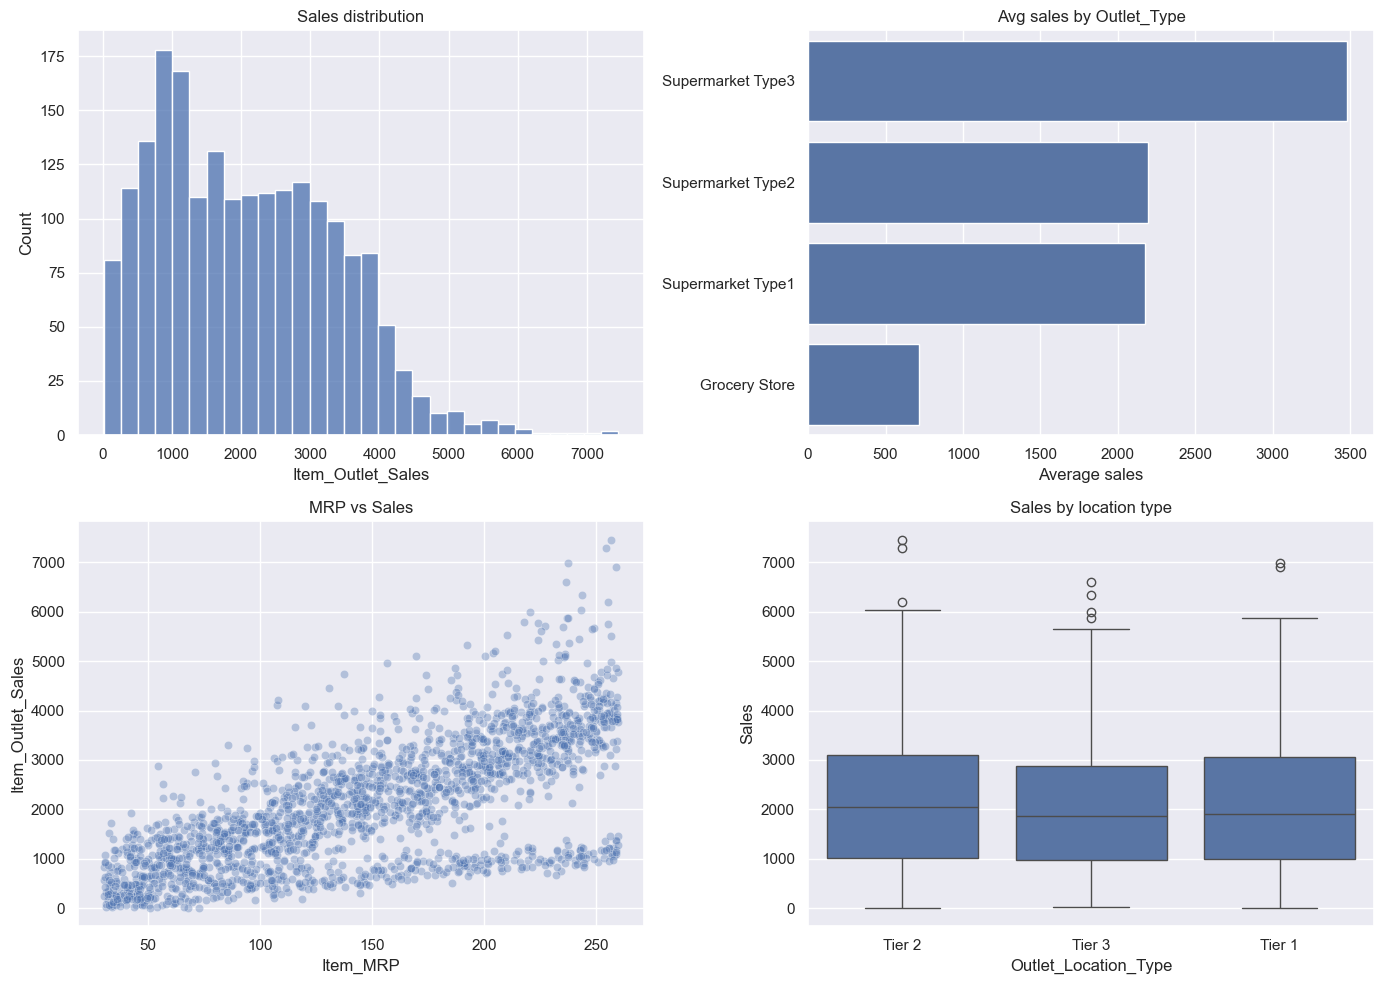

In [ ]:
# M3 — Mini dashboard 4 plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Target distribution sales
sns.histplot(df["Item_Outlet_Sales"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Sales distribution")
axes[0, 0].set_xlabel("Item_Outlet_Sales")

# 2) Average sales by Outlet_Type
outlet_means = df.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)
sns.barplot(x=outlet_means.values, y=outlet_means.index, ax=axes[0, 1])
axes[0, 1].set_title("Avg sales by Outlet_Type")
axes[0, 1].set_xlabel("Average sales")
axes[0, 1].set_ylabel("")

# 3) Price MRP vs Sales
sns.scatterplot(data=df, x="Item_MRP", y="Item_Outlet_Sales", alpha=0.35, ax=axes[1, 0])
axes[1, 0].set_title("MRP vs Sales")

# 4) Boxplot: Sales by Outlet_Location_Type
sns.boxplot(data=df, x="Outlet_Location_Type", y="Item_Outlet_Sales", ax=axes[1, 1])
axes[1, 1].set_title("Sales by location type")
axes[1, 1].set_xlabel("Outlet_Location_Type")
axes[1, 1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

## M4  Introduction to Machine Learning optional

We’ll do a **simple regression** model to predict sales. This is optional. The main goal is data analysis and decision making.

Key idea: split the data into train and test and evaluate with MAE and RMSE.

In [ ]:
# M4 — Simple regression baseline scikit learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

target = "Item_Outlet_Sales"
numeric_features = ["Item_Weight", "Item_Visibility", "Item_MRP"]
categorical_features = ["Item_Fat_Content", "Outlet_Size", "Outlet_Type", "Outlet_Location_Type", "Item_Type"]

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",
)

model = Pipeline(steps=[("preprocess", preprocess), ("reg", LinearRegression())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE : 427.62
RMSE: 534.01


## From raw data to strategic decisions business summary

This final section is the *deliverable mindset*: we convert analysis into clear, action oriented recommendations.

,total_sales,avg_sales,n_rows
Outlet_Type,,,
Supermarket Type1,2.525079e+06,2176.791913,1160
Supermarket Type3,7.170468e+05,3480.809698,206
Supermarket Type2,7.064298e+05,2193.881376,322
Grocery Store,2.231205e+05,715.129847,312


,total_sales,avg_sales,n_rows
Item_Type,,,
Dairy,570177.986241,2135.498076,267
Household,565126.055613,2116.576987,267
Fruits and Vegetables,563738.821921,2135.374325,264
Meat,518903.479921,2198.743559,236
Frozen Foods,515736.183879,1960.974083,263
Soft Drinks,488330.432764,1993.185440,245
Baking Goods,486857.224272,2037.059516,239
Snack Foods,462805.547283,2113.267339,219


,mean,median,count
MRP_band,,,
High,3113.684307,3297.162705,667
Mid,2110.329761,2157.343796,666
Low,1033.536250,975.802723,667


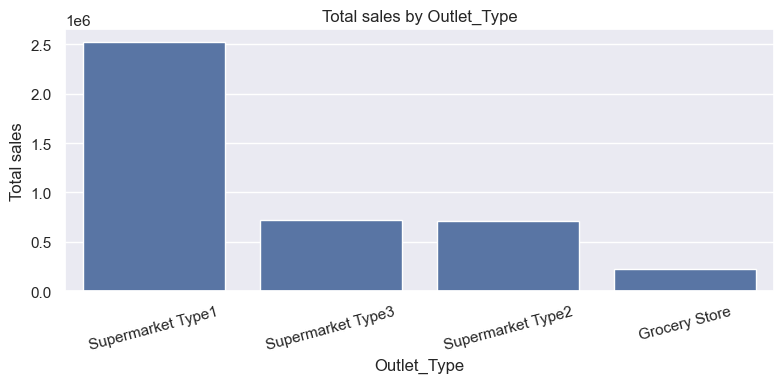

In [ ]:
# Strategic KPIs: where to focus simple, decision ready tables
# 1) Total + average sales by Outlet_Type
kpi_outlet_type = (
    df.groupby("Outlet_Type")
    .agg(total_sales=("Item_Outlet_Sales", "sum"), avg_sales=("Item_Outlet_Sales", "mean"), n_rows=("Item_Outlet_Sales", "size"))
    .sort_values("total_sales", ascending=False)
 )
display(kpi_outlet_type)

# 2) Total sales by Item_Type top 10
kpi_item_type = (
    df.groupby("Item_Type")
    .agg(total_sales=("Item_Outlet_Sales", "sum"), avg_sales=("Item_Outlet_Sales", "mean"), n_rows=("Item_Outlet_Sales", "size"))
    .sort_values("total_sales", ascending=False)
 )
display(kpi_item_type.head(10))

# 3) Price bands: low / mid / high MRP and average sales in each band
df_tmp = df.copy()
df_tmp["MRP_band"] = pd.qcut(df_tmp["Item_MRP"], q=3, labels=["Low", "Mid", "High"])
kpi_price_band = (
    df_tmp.groupby("MRP_band", observed=True)["Item_Outlet_Sales"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
 )
display(kpi_price_band)

# Quick plot: total sales by Outlet_Type
plt.figure(figsize=(8, 4))
sns.barplot(x=kpi_outlet_type.index, y=kpi_outlet_type["total_sales"].values)
plt.title("Total sales by Outlet_Type")
plt.xlabel("Outlet_Type")
plt.ylabel("Total sales")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()